In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

# Load dataset
df = pd.read_csv(r"C:\Users\User\OneDrive\文档\project\sentiment prject\Amazon-Product-Reviews - Amazon Product Review (1).csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Shape: (30846, 16)

Columns: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'sentiment']


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [77]:
# Drop missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (30840, 16)


In [78]:
## Label sentiment based on star_rating
df['sentiment'] = df['star_rating'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

print(df['sentiment'].value_counts())

sentiment
positive    25763
negative     2861
neutral      2216
Name: count, dtype: int64


In [79]:
print(df.columns.tolist())

['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'sentiment']


In [80]:
# See ALL column names clearly
for col in df.columns:
    print(col)

marketplace
customer_id
review_id
product_id
product_parent
product_title
product_category
star_rating
helpful_votes
total_votes
vine
verified_purchase
review_headline
review_body
review_date
sentiment


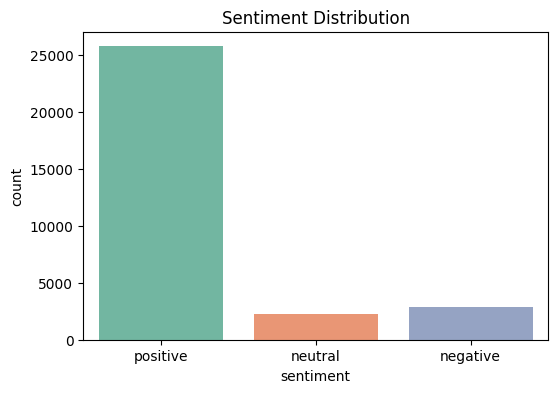

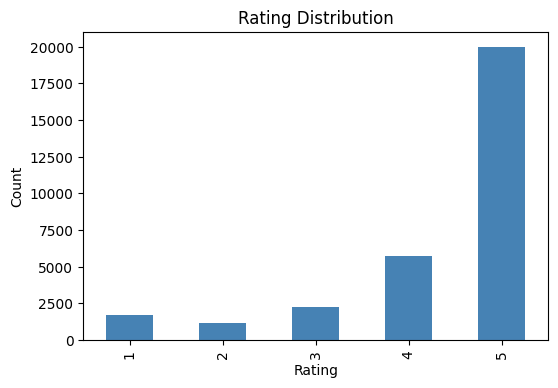

In [81]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution')
plt.show()

plt.figure(figsize=(6,4))
df['star_rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

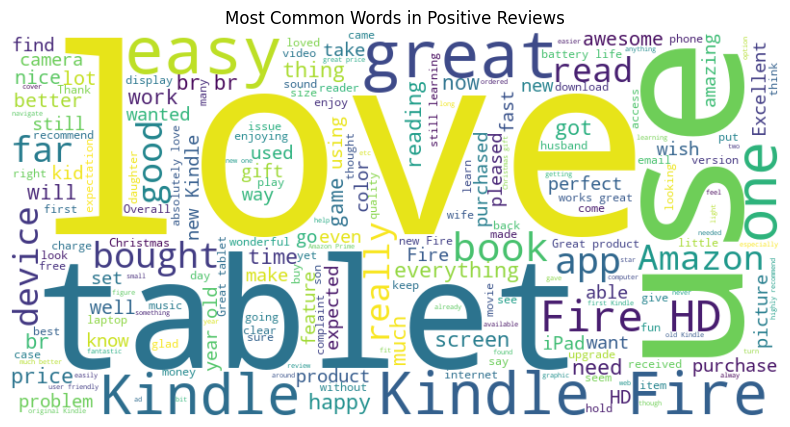

In [82]:
positive_text = ' '.join(df[df['sentiment']=='positive']['review_body'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

In [83]:
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [ps.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['review_body'].apply(preprocess)
print("Text preprocessing done!")
df[['review_body', 'clean_text']].head()

Text preprocessing done!


,review_body,clean_text
0,Great love it,great love
1,Lots of ads<br />Slow processing speed<br />Oc...,lot adsbr slow process speedbr occasion shut a...
2,Excellent unit. The versatility of this table...,excel unit versatil tablet besid competit pric...
3,I bought this on Amazon Prime so I ended up bu...,bought amazon prime end buy 16gb one 95 camera...
4,All Amazon products continue to meet my expect...,amazon product continu meet expect


In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8526264591439688

Classification Report:
               precision    recall  f1-score   support

    negative       0.76      0.24      0.36       566
     neutral       0.50      0.00      0.01       461
    positive       0.86      1.00      0.92      5141

    accuracy                           0.85      6168
   macro avg       0.71      0.41      0.43      6168
weighted avg       0.82      0.85      0.80      6168



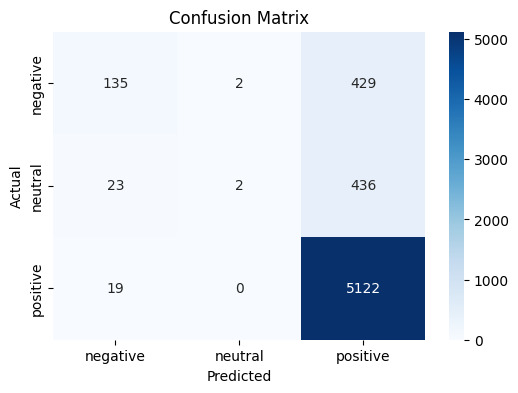

In [85]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [86]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Total Reviews Analyzed: {len(df)}")
print(f"\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nModel Accuracy: {round(accuracy_score(y_test, y_pred)*100, 2)}%")
print("\nConclusion: Naive Bayes successfully classifies Amazon reviews!")

PROJECT SUMMARY
Total Reviews Analyzed: 30840

Sentiment Distribution:
sentiment
positive    25763
negative     2861
neutral      2216
Name: count, dtype: int64

Model Accuracy: 85.26%

Conclusion: Naive Bayes successfully classifies Amazon reviews!
